# Read and plot the original source

Same complete `Fig_S6B` readout and plotting options as `read_atst.ipynb`. Source ranges and condition annotations remain explicit; no ATST file is read. Matplotlib plots the source values directly.


In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from openpyxl import load_workbook

readout_id = "Fig_S6B"
rows, curves = [], []

sheet = load_workbook(
    "read_shared_data/sources/raw_data_set_wraf065.xlsx", read_only=True, data_only=True
)["Figure S6"]
time = [row[0].value for row in sheet["I9:I153"]]
for treatment, first in [
    ("untreated", 10),
    ("Bhz17", 13),
    ("JG005+JG024", 16),
    ("JG005+JG024+Bhz17", 19),
]:
    for replicate, column in enumerate(range(first, first + 3), 1):
        rows.append(
            {
                "type": "uninfected_control"
                if treatment == "untreated"
                else "phage_exposed",
                "treatment": treatment,
                "replicate": str(replicate),
            }
        )
        curves.append(
            pd.Series([sheet.cell(r, column).value for r in range(9, 154)], index=time)
        )

# Local curve IDs preserve source order; different time grids align without interpolation.
layout = pd.DataFrame(rows)
layout["curve_id"] = [f"curve_{i}" for i in range(1, len(rows) + 1)]
readings = pd.concat(curves, axis=1).sort_index()
readings.columns = layout["curve_id"]
readings = readings.rename_axis("Time").reset_index()


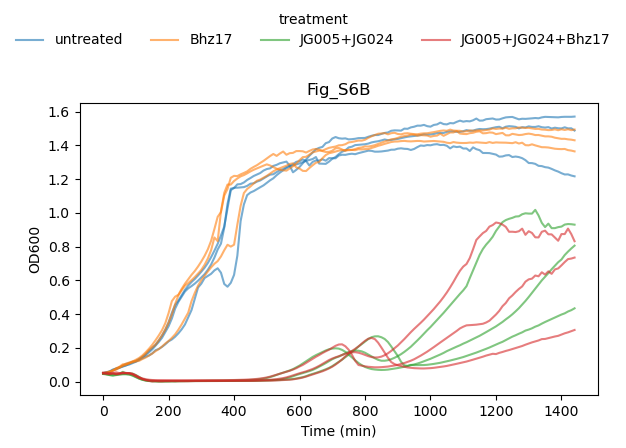

In [2]:
panels = [(None, layout)]
ncols = min(2, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby("treatment", sort=False):
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = str(condition)
        values = readings[group["curve_id"]]
        for index, curve_id in enumerate(group["curve_id"]):
            ax.plot(
                readings["Time"],
                readings[curve_id],
                color=color,
                alpha=0.6,
                label=label if index == 0 else None,
            )
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("OD600")
    ax.set_title(readout_id)

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)
legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='treatment', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()


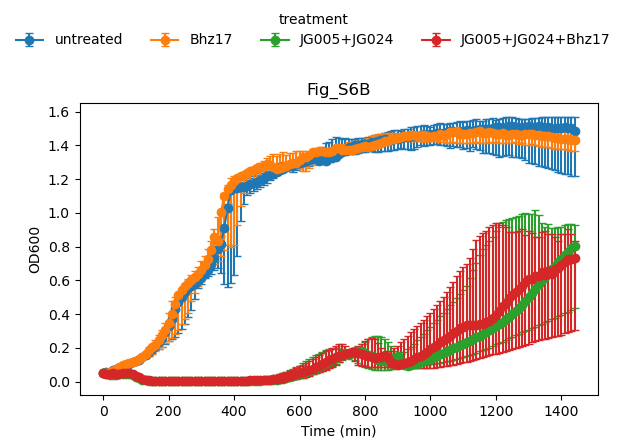

In [3]:
panels = [(None, layout)]
ncols = min(2, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby("treatment", sort=False):
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = str(condition)
        values = readings[group["curve_id"]]
        median = values.median(axis=1)
        minimum = values.min(axis=1)
        maximum = values.max(axis=1)
        ax.errorbar(
            readings["Time"],
            median,
            yerr=[median - minimum, maximum - median],
            fmt="o-",
            capsize=3,
            color=color,
            label=label,
        )
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("OD600")
    ax.set_title(readout_id)

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)
legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='treatment', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()
